In [4]:
from glob import glob

files = glob("outputs/**/*predictions*.csv", recursive=True)
print(files)

dfs = []

for f in files:
    tmp = pd.read_csv(f)
    
    if "actual" in tmp.columns and "actual_energy_per_atom" not in tmp.columns:
        tmp = tmp.rename(columns={"actual": "actual_energy_per_atom"})
    
    if "predicted" in tmp.columns and "predicted_energy_per_atom" not in tmp.columns:
        tmp = tmp.rename(columns={"predicted": "predicted_energy_per_atom"})
    
    if "model" not in tmp.columns:
        name = f.split("/")[-1].replace("_predictions.csv", "")
        tmp["model"] = name
    
    dfs.append(tmp)

predictions_df = pd.concat(dfs, ignore_index=True)

predictions_df["error"] = predictions_df["predicted_energy_per_atom"] - predictions_df["actual_energy_per_atom"]
predictions_df["absolute_error"] = predictions_df["error"].abs()
predictions_df["error_meV"] = predictions_df["error"] * 1000
predictions_df["absolute_error_meV"] = predictions_df["absolute_error"] * 1000

display(predictions_df.head())

['outputs\\pytorch_mlp\\pytorch_mlp_predictions.csv', 'outputs\\random_forest\\random_forest_predictions.csv', 'outputs\\xgboost\\xgboost_predictions.csv']


,actual_energy_per_atom,predicted_energy_per_atom,error,absolute_error,model,error_meV,absolute_error_meV
0,-154.546684,-154.52705,0.019634,0.019634,outputs\pytorch_mlp\pytorch_mlp,19.634000,19.634000
1,-154.159400,-154.15366,0.005740,0.005740,outputs\pytorch_mlp\pytorch_mlp,5.739500,5.739500
2,-154.158839,-154.14948,0.009359,0.009359,outputs\pytorch_mlp\pytorch_mlp,9.358667,9.358667
3,-154.313358,-154.29485,0.018508,0.018508,outputs\pytorch_mlp\pytorch_mlp,18.508167,18.508167
4,-154.305662,-154.26938,0.036282,0.036282,outputs\pytorch_mlp\pytorch_mlp,36.282000,36.282000


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/regression/figures/outputs\\pytorch_mlp\\pytorch_mlp_residual_plot.png'

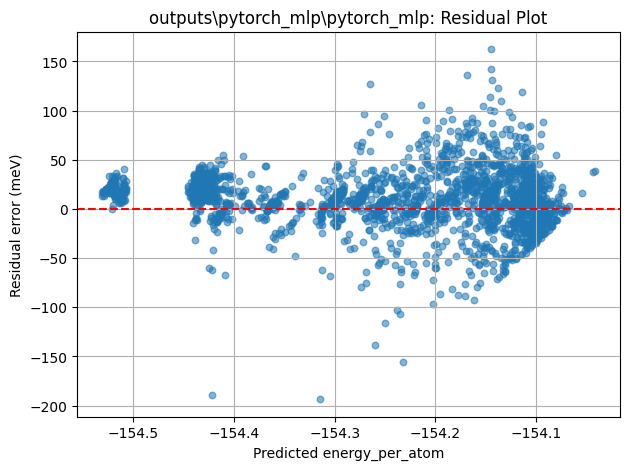

In [5]:
import os

FIG_DIR = "outputs/regression/figures"
os.makedirs(FIG_DIR, exist_ok=True)

for model_name in predictions_df["model"].unique():
    temp = predictions_df[predictions_df["model"] == model_name]
    
    plt.figure(figsize=(7, 5))
    
    plt.scatter(
        temp["predicted_energy_per_atom"],
        temp["error_meV"],
        alpha=0.55,
        s=22
    )
    
    plt.axhline(0, color="red", linestyle="--")
    
    plt.xlabel("Predicted energy_per_atom")
    plt.ylabel("Residual error (meV)")
    plt.title(f"{model_name}: Residual Plot")
    plt.grid(True)
    
    plt.savefig(
        f"{FIG_DIR}/{model_name}_residual_plot.png",
        dpi=200,
        bbox_inches="tight"
    )
    
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/regression/figures/outputs\\pytorch_mlp\\pytorch_mlp_error_distribution.png'

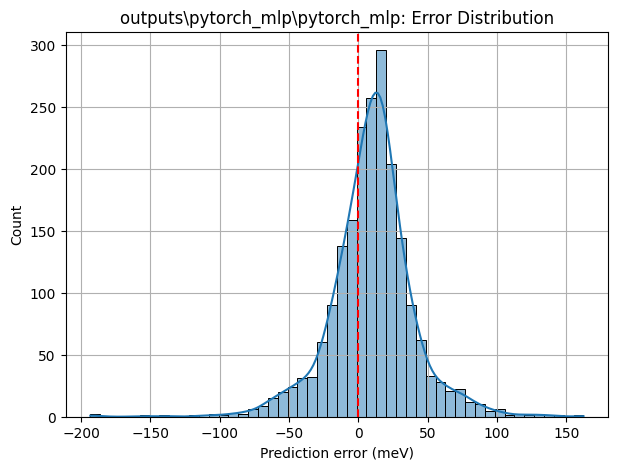

In [6]:
for model_name in predictions_df["model"].unique():
    temp = predictions_df[predictions_df["model"] == model_name]
    
    plt.figure(figsize=(7, 5))
    
    sns.histplot(
        temp["error_meV"],
        bins=50,
        kde=True
    )
    
    plt.axvline(0, color="red", linestyle="--")
    
    plt.xlabel("Prediction error (meV)")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Error Distribution")
    plt.grid(True)
    
    plt.savefig(
        f"{FIG_DIR}/{model_name}_error_distribution.png",
        dpi=200,
        bbox_inches="tight"
    )
    
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/regression/figures/outputs\\pytorch_mlp\\pytorch_mlp_absolute_error_vs_actual_energy.png'

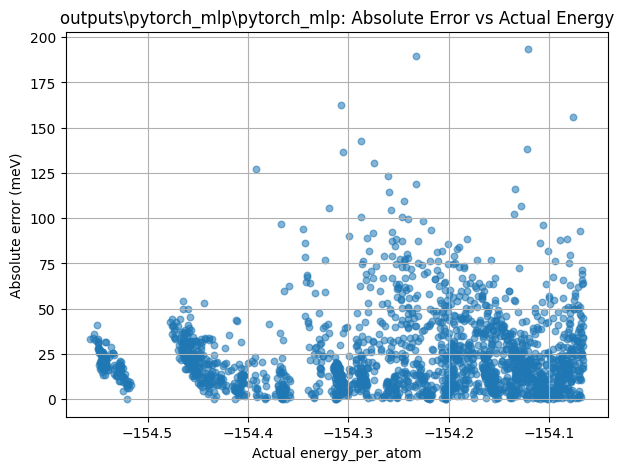

In [7]:
for model_name in predictions_df["model"].unique():
    temp = predictions_df[predictions_df["model"] == model_name]
    
    plt.figure(figsize=(7, 5))
    
    plt.scatter(
        temp["actual_energy_per_atom"],
        temp["absolute_error_meV"],
        alpha=0.55,
        s=22
    )
    
    plt.xlabel("Actual energy_per_atom")
    plt.ylabel("Absolute error (meV)")
    plt.title(f"{model_name}: Absolute Error vs Actual Energy")
    plt.grid(True)
    
    plt.savefig(
        f"{FIG_DIR}/{model_name}_absolute_error_vs_actual_energy.png",
        dpi=200,
        bbox_inches="tight"
    )
    
    plt.show()

In [8]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=regression_summary.sort_values("RMSE_meV"),
    x="model",
    y="RMSE_meV",
    color="steelblue"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Model")
plt.ylabel("RMSE (meV)")
plt.title("Regression Model Comparison by RMSE")
plt.grid(True, axis="y")

plt.savefig(f"{FIG_DIR}/model_comparison_rmse.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))

sns.barplot(
    data=regression_summary.sort_values("MAE_meV"),
    x="model",
    y="MAE_meV",
    color="darkorange"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Model")
plt.ylabel("MAE (meV)")
plt.title("Regression Model Comparison by MAE")
plt.grid(True, axis="y")

plt.savefig(f"{FIG_DIR}/model_comparison_mae.png", dpi=200, bbox_inches="tight")
plt.show()


plt.figure(figsize=(9, 5))

sns.barplot(
    data=regression_summary.sort_values("R2", ascending=False),
    x="model",
    y="R2",
    color="seagreen"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Model")
plt.ylabel("R²")
plt.title("Regression Model Comparison by R²")
plt.grid(True, axis="y")

plt.savefig(f"{FIG_DIR}/model_comparison_r2.png", dpi=200, bbox_inches="tight")
plt.show()

NameError: name 'regression_summary' is not defined

<Figure size 900x500 with 0 Axes>

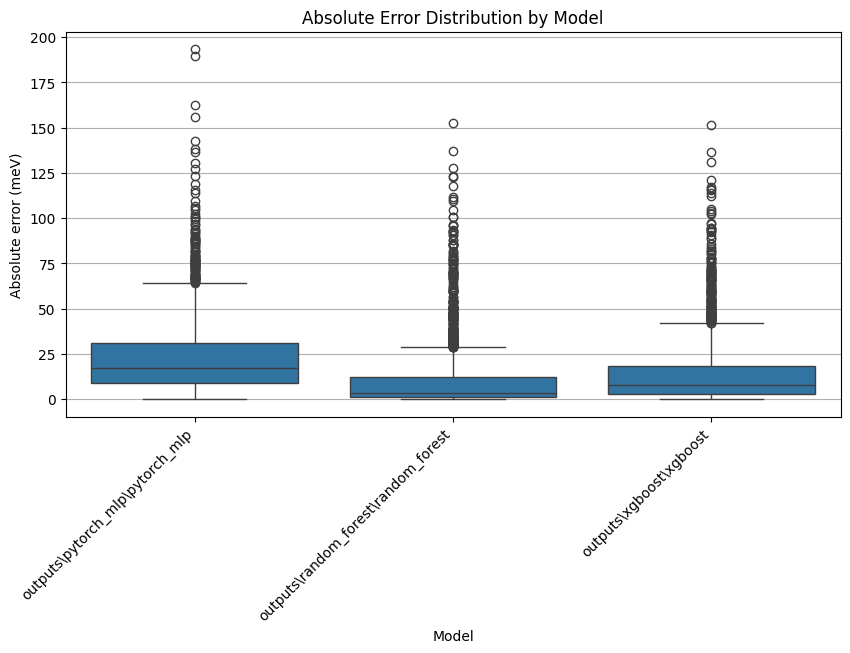

In [9]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=predictions_df,
    x="model",
    y="absolute_error_meV"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Model")
plt.ylabel("Absolute error (meV)")
plt.title("Absolute Error Distribution by Model")
plt.grid(True, axis="y")

plt.savefig(f"{FIG_DIR}/absolute_error_boxplot_by_model.png", dpi=200, bbox_inches="tight")
plt.show()

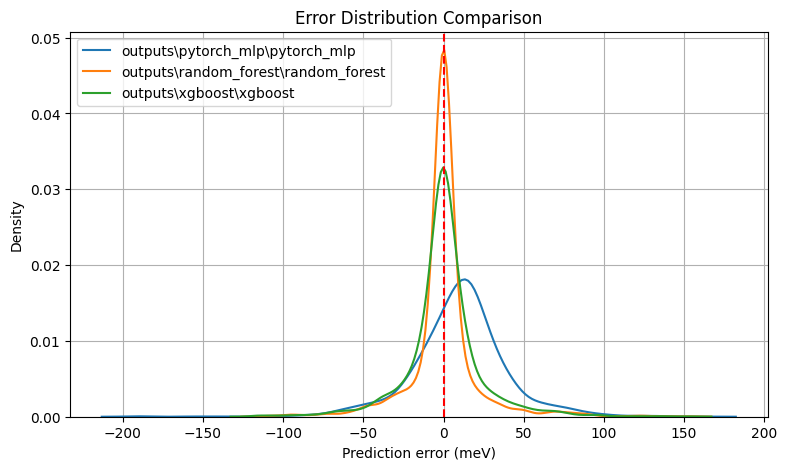

In [10]:
plt.figure(figsize=(9, 5))

for model_name in predictions_df["model"].unique():
    temp = predictions_df[predictions_df["model"] == model_name]
    
    sns.kdeplot(
        temp["error_meV"],
        label=model_name,
        fill=False
    )

plt.axvline(0, color="red", linestyle="--")

plt.xlabel("Prediction error (meV)")
plt.ylabel("Density")
plt.title("Error Distribution Comparison")
plt.legend()
plt.grid(True)

plt.savefig(f"{FIG_DIR}/error_distribution_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

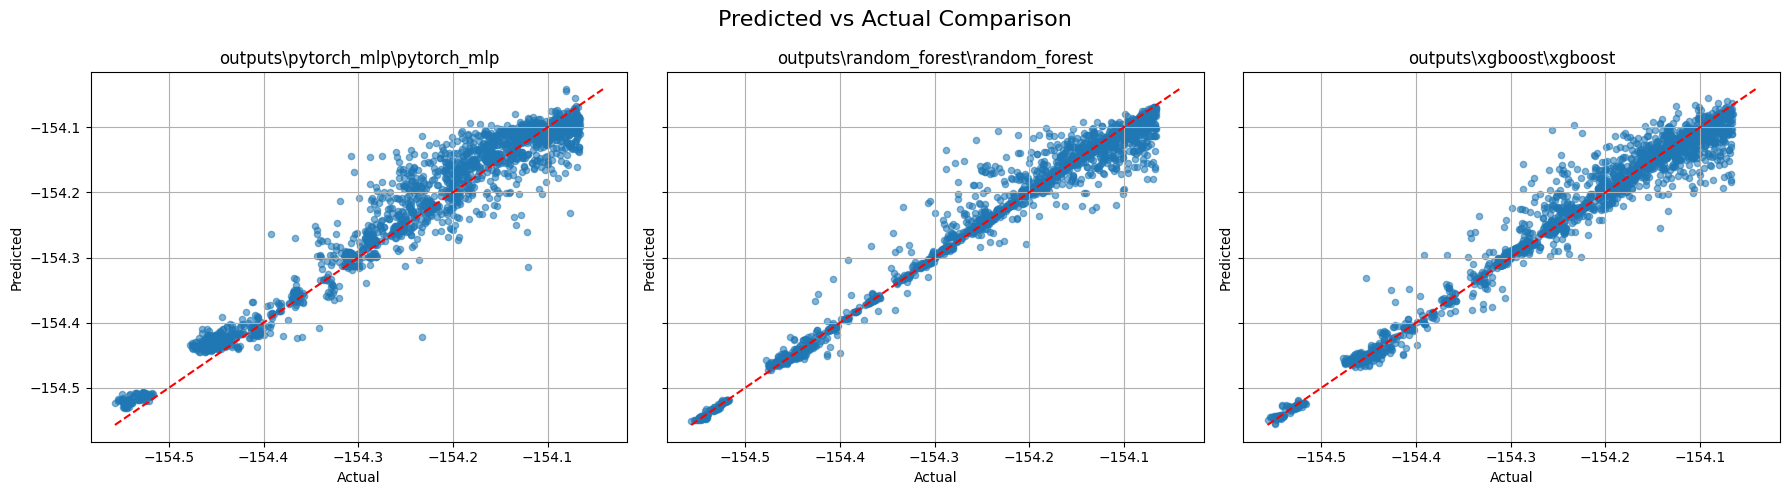

In [12]:
models = predictions_df["model"].unique()
n_models = len(models)

fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), sharex=True, sharey=True)

if n_models == 1:
    axes = [axes]

global_min = min(
    predictions_df["actual_energy_per_atom"].min(),
    predictions_df["predicted_energy_per_atom"].min()
)
global_max = max(
    predictions_df["actual_energy_per_atom"].max(),
    predictions_df["predicted_energy_per_atom"].max()
)

for ax, model_name in zip(axes, models):
    temp = predictions_df[predictions_df["model"] == model_name]
    
    ax.scatter(
        temp["actual_energy_per_atom"],
        temp["predicted_energy_per_atom"],
        alpha=0.55,
        s=20
    )
    
    ax.plot([global_min, global_max], [global_min, global_max], "r--")
    ax.set_title(model_name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(True)

plt.suptitle("Predicted vs Actual Comparison", fontsize=16)
plt.tight_layout()

plt.savefig(f"{FIG_DIR}/predicted_vs_actual_all_models.png", dpi=200, bbox_inches="tight")
plt.show()

In [13]:
cluster_df = pd.read_csv("data/kmeans_cluster_assignments_best.csv")

if "row_index" in predictions_df.columns and "row_index" in cluster_df.columns:
    pred_cluster = predictions_df.merge(
        cluster_df[["row_index", "cluster_kmeans"]],
        on="row_index",
        how="left"
    )
    
    plt.figure(figsize=(10, 5))
    
    sns.boxplot(
        data=pred_cluster,
        x="cluster_kmeans",
        y="absolute_error_meV",
        hue="model"
    )
    
    plt.xlabel("KMeans cluster")
    plt.ylabel("Absolute error (meV)")
    plt.title("Prediction Error by KMeans Cluster")
    plt.grid(True, axis="y")
    
    plt.savefig(f"{FIG_DIR}/prediction_error_by_kmeans_cluster.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Không có row_index để merge prediction với cluster.")

FileNotFoundError: [Errno 2] No such file or directory: 'data/kmeans_cluster_assignments_best.csv'